# MONTE CARLO OF SURFACES WITH FREE BOUNDARY

## Motivation

Let us consider that we want to simulate a solid 2D membrane or ribbon. How do we study the elastic deformations of the membrane under thermal fluctuations? Although the most accurate approach would be to try to compute the entire continuum structure, it is impossible for a computer to solve for a continuous physical field over an infinite number of points. We discretise the structure into a mesh - specifically, a triangulated mesh.The total bending energy is given by,$$H_{bend}=\int dA\bigg(\frac{\kappa}{2}(\nabla^2f)^2+\bar{\kappa}K_G\bigg)$$where $\kappa$ is the bending modulus and $\bar{\kappa}$ is the saddle-splay modulus.To compute this energy on our mesh, the existing MeMC algorithm has provision for either closed boundary, or clamped boundary conditions. Closed boundary condition implies there are no boundary vertices, e.g. in a sphere, and clamped boundary means we simply exclude the boundary vertices from the Monte Carlo updates, as a result of which we do not need to handle the energy at the boundary vertices at all. 

The Gauss-Bonnet Theorem states that, for a manifold $M$ with a boundary which we denote by $m$,$$\int_M K_GdA+\int _m \kappa_gds=2\pi \chi (M)$$For a surface that does not have an open boundary, the geodesic curvature term simply vanishes. As a result the Gaussian curvature term is an irrelevant constant, which does not affect the energy change in our Monte Carlo updates.

Now, when we are trying to implement a stress-free boundary, which is necessary if we want to simulate a truly free-floating membrane or ribbon rather than a clamped one, or if we want to study the dynamics of pores, where an open boundary is unavoidable, we can no longer disregard the Gaussian curvature term.

*Strategy: To compute the area integral of the Gaussian curvature, from the line integral of the geodesic curvature over the boundary.*

So, the problem of how to handle the bending energy for a stress-free boundary factors into computing the geodesic curvature at the boundary. If we can determine the tangent and normal at the surface, we can directly use the formula for geodesic curvature,$$\kappa_g=\frac{d\vec T}{ds} \cdot (\vec N\times \vec{T})$$where $\vec{N}$ is the unit normal of the surface, and $\vec T$ is the unit tangent.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from numba import njit

### Central Finite Difference Formulae for Uneven Step Length

Reference: Singh, Ashok & Bhadauria, Beer. (2009). Finite Difference Formulae for Unequal Sub-Intervals Using Lagrange's Interpolation Formula. Journal of Math. Analysis. 3. 815-827. 

In [4]:
#helper functions to compute first and second derivatives by central finite difference

#THREE POINT FORMULAE WITH UNEVEN STEP SIZE

#first derivative
def threept_fd1(xm1,x,xp1): 
    h2=np.linalg.norm(xp1-x)
    h1=np.linalg.norm(x-xm1)
    d1=h2*xm1/(h1*(h1+h2))
    d2=(h1-h2)*x/(h1*h2)
    d3=h1*xp1/(h2*(h1+h2))
    return -d1-d2+d3

#second derivative
def threept_fd2(xm1,x,xp1):
    h2=np.linalg.norm(xp1-x)
    h1=np.linalg.norm(x-xm1)
    return 2*(h2*xm1-(h1+h2)*x+h1*xp1)/(h1*h2*(h1+h2))

#FIVE POINT FORMULAE WITH UNEVEN STEP SIZE

#first derivative
def fivept_fd1(xm2,xm1,x,xp1,xp2):
    h1=np.linalg.norm(xm1-xm2)
    h2=np.linalg.norm(x-xm1)
    h3=np.linalg.norm(xp1-x)
    h4=np.linalg.norm(xp2-xp1)
    H1=h1+h2+h3
    H2=h1+h2+h3+h4
    d1=h2*h3*(h3+h4)*xm2/(h1*(h1+h2)*H1*H2)
    d2=(h1+h2)*h3*(h3+h4)*xm1/(h1*h2*(h2+h3)*(H2-h1))
    d3=((h1+2*h2)*h3*(h3+h4)-(h1+h2)*h2*(2*h3+h4))*x/((h1+h2)*h2*h3*(h3+h4))
    d4=(h1+h2)*h2*(h3+h4)*xp1/(H1*(h2+h3)*h3*h4)
    d5=(h1+h2)*h2*h3*xp2/(H2*(H2-h1)*(h3+h4)*h4)
    return d1-d2+d3+d4-d5

#second derivative
def fivept_fd2(xm2,xm1,x,xp1,xp2):
    h1=np.linalg.norm(xm1-xm2)
    h2=np.linalg.norm(x-xm1)
    h3=np.linalg.norm(xp1-x)
    h4=np.linalg.norm(xp2-xp1)
    H1=h1+h2+h3
    H2=h1+h2+h3+h4
    d1=(-2*h2*(2*h3+h4)+2*h3*(h3+h4))*xm2/(h1*(h1+h2)*(h1+h2+h3)*H2)
    d2=(2*(h1+h2)*(2*h3+h4)-2*h3*(h3+h4))*xm1/(h1*h2*(h2+h3)*(h2+h3+h4))
    d3=(2*h2*(h1+h2)-2*(h1+2*h2)*(2*h3+h4)+2*h3*(h3+h4))*x/((h1+h2)*h2*h3*(h3+h4))
    d4=(2*(h1+2*h2)*(h3+h4)-2*h2*(h1+h2))*xp1/((h1+h2+h3)*(h2+h3)*h3*h4)
    d5=(2*(h1+h2)*h2-2*(h1+2*h2)*h3)*xp2/(H2*(h2+h3+h4)*(h3+h4)*h4)
    return d1+d2+d3+d4+d5  

### Initialization of the Surface

We follow the algorithm implemented in the MeMC code. 

In [5]:
def init(N,lenx,leny,bdry):
    
    pts=np.zeros((N,2))
    
    nghost=int(np.sqrt(N))
    nghostx=int(2*nghost*lenx/(lenx+leny)) #total number of ghost particles including botb top and bottom
    nghosty=int(2*nghost*leny/(lenx+leny))

    dlx=lenx/nghostx
    dly=leny/nghosty #spacing between ghost particles
    if bdry=="cyl": #periodic (channel) boundary in x direction
        nghost=2*nghostx
        n_int=N-nghost
        
        pts[:nghostx,0]=np.arange(nghostx)*dlx
        pts[:nghostx,1]=0.0 
        
        #top edge shift by 0.5*dlx
        pts[nghostx:nghost,0]=(np.arange(nghostx)+0.5)*dlx
        pts[nghostx:nghost,1]=leny

        pts[nghost:,0]=np.random.uniform(0,lenx,n_int)
        pts[nghost:,1]=np.random.uniform(dly,leny-dly,n_int)
    elif bdry=="frame":
        nghost=2*nghostx+2*nghosty
        n_int=N-nghost

        pts[:nghostx,0]=(np.arange(nghostx)+0.5)*dlx
        pts[:nghostx,1]=0.0

        pts[nghostx:2*nghostx,0]=(np.arange(nghostx)+0.5)*dlx
        pts[nghostx:2*nghostx,1]=leny

        pts[2*nghostx:2*nghostx+nghosty,0]=0.0
        pts[2*nghostx:2*nghostx+nghosty,1]=((np.arange(nghosty)+0.5)*dly)

        pts[2*nghostx+nghosty:nghost,0]=lenx
        pts[2*nghostx+nghosty:nghost,1]=((np.arange(nghosty)+0.5)*dly)

        pts[nghost:,0]=np.random.uniform(dlx,lenx-dlx,n_int)
        pts[nghost:,1]=np.random.uniform(dly,leny-dly,n_int)
    elif bdry=="rect":
        nghost=2*nghostx+2*nghosty
        n_int=N-nghost

        pts[:nghostx,0]=(np.arange(nghostx))*dlx
        pts[:nghostx,1]=0.0

        pts[nghostx:2*nghostx,0]=(np.arange(nghostx)+1)*dlx
        pts[nghostx:2*nghostx,1]=leny

        pts[2*nghostx:2*nghostx+nghosty,0]=0.0
        pts[2*nghostx:2*nghostx+nghosty,1]=((np.arange(nghosty)+1)*dly)

        pts[2*nghostx+nghosty:nghost,0]=lenx
        pts[2*nghostx+nghosty:nghost,1]=((np.arange(nghosty))*dly)

        pts[nghost:,0]=np.random.uniform(dlx,lenx-dlx,n_int)
        pts[nghost:,1]=np.random.uniform(dly,leny-dly,n_int)
        
    return pts,nghost
    

In [6]:
@njit
def ljpairenergy(vertind,pts2d,lenx,leny,sigma,eps,rc,dfac,kBT,bdry):
    dx=pts2d[:,0]-pts2d[vertind,0]
    dy=pts2d[:,1]-pts2d[vertind,1]

    if bdry=="cyl":
        dx=dx-lenx*np.round(dx/lenx)

    ds2=dx**2+dy**2
    ds2[vertind]=np.inf #self
    '''
    energy=0.0
    
    for i in range(len(ds2)):
        if ds2[i]<rc**2:
            r6=(sigma**2/ds2)**3
            energy+=eps*r6*(r6-1.0)
    '''
    ds2=ds2[ds2<rc**2]

    if len(ds2)==0:
        return 0.0

    r6=(sigma**2/ds2)**3
    energy=np.sum(eps*r6*(r6-1.0))
    
    return energy    

In [194]:
def mc2d(pts2d,nghost,lenx,leny,sigma,eps,rc,dfac,kBT,onemciter,bdry):
    N=len(pts2d)
    accepted=0
    for _ in range(onemciter):
        vertind=np.random.randint(nghost,N)
        Eold=ljpairenergy(vertind,pts2d,lenx,leny,sigma,eps,rc,dfac,kBT,bdry)
        x0,y0=pts2d[vertind].copy()
        dx=(sigma/dfac)*np.random.uniform(-1,1)
        dy=(sigma/dfac)*np.random.uniform(-1,1)
        if bdry=="cyl":
            if y0+dy<0 or y0+dy>leny:
                continue
            pts2d[vertind,0]=(x0+dx)%lenx #update the position
            pts2d[vertind,1]=(y0+dy)
        elif bdry=="frame" or bdry=="rect":
            if x0+dx<0 or x0+dx>lenx or y0+dy<0 or y0+dy>leny:
                continue
            pts2d[vertind,0]=(x0+dx) #update the position
            pts2d[vertind,1]=(y0+dy)
            
        Enew=ljpairenergy(vertind,pts2d,lenx,leny,sigma,eps,rc,dfac,kBT,bdry)
        dE=Enew-Eold
        if dE<=0.0 or np.random.rand()<np.exp(-dE/kBT):
            accepted+=1
        else:
            pts2d[vertind,0]=x0
            pts2d[vertind,1]=y0
    return accepted

In [195]:
#run the equilibriation on flat surface, periodic over x coordinate only

def run_init_eq(N,lenx,leny,sigma,eps,rc,dfac,kBT,onemciter,totmciter,bdry):    
    pts2d,nghost=init(N,lenx,leny,bdry)
    for i in range(totmciter):
        accepted=mc2d(pts2d,nghost,lenx,leny,sigma,eps,rc,dfac,kBT,onemciter,bdry)
        if i%100==0:
            print(i,"Accepted moves=",100*accepted/onemciter,"%")
    
    #now the pts2d array should be accordingly equilibriated
    return pts2d,nghost

### Triangulation

In [196]:
#postprocess to get the triangulation
#standard 2d triangulation

def triangulate(pts2d,nghost,lenx,leny,bdry):
    N=len(pts2d)
    tri=Delaunay(pts2d,furthest_site=False)
    simplices=tri.simplices

    nbrs=[set() for _ in range(N)]
    #construct neighbour list
    for v0,v1,v2 in simplices:
        nbrs[v0].update([v1,v2])
        nbrs[v1].update([v0,v2])
        nbrs[v2].update([v0,v1])

    sortednbrs=[] #construct the neighbour list traversing anticlockwise
    for i in range(N):
        nodenbrs=list(nbrs[i])
        dx=pts2d[nodenbrs,0]-pts2d[i,0]
        dy=pts2d[nodenbrs,1]-pts2d[i,1]
        angles=np.arctan2(dy,dx)

        sortednodenbrs=np.array(nodenbrs)[np.argsort(angles)]
        sortednbrs.append(sortednodenbrs.tolist())
    return tri.simplices, sortednbrs


### Extracting the Boundary Indices and Running the Initialisation

In [197]:
def bdryindices(N,lenx,leny,bdry): #extract the boundary loop
    nghost=int(np.sqrt(N))
    nghostx=int(2*nghost*lenx/(lenx+leny))
    nghosty=int(2*nghost*leny/(lenx+leny))

    bdryloops={}

    if bdry=="cyl":
        bdryloops["bot"]=list(range(0,nghostx))
        bdryloops["top"]=list(range(nghostx,2*nghostx))

    elif bdry=="frame" or bdry=="rect":
        bdryloops["bot"]=list(range(0,nghostx))
        bdryloops["top"]=list(range(nghostx,2*nghostx))
        bdryloops["left"]=list(range(2*nghostx,2*nghostx+nghosty))
        bdryloops["right"]=list(range(2*nghostx+nghosty,2*nghostx+2*nghosty))

    return bdryloops

In [423]:
#Define the parameters
lenx=2*np.pi
leny=np.pi/4
N=1024
sigma=np.sqrt((lenx*leny)/N)
eps=1.0
kBT=1.0
rc=4*sigma
dfac=14
onemciter=2*N
totmciter=3000
KBT=1
#dump_skip=100
bdry="rect"

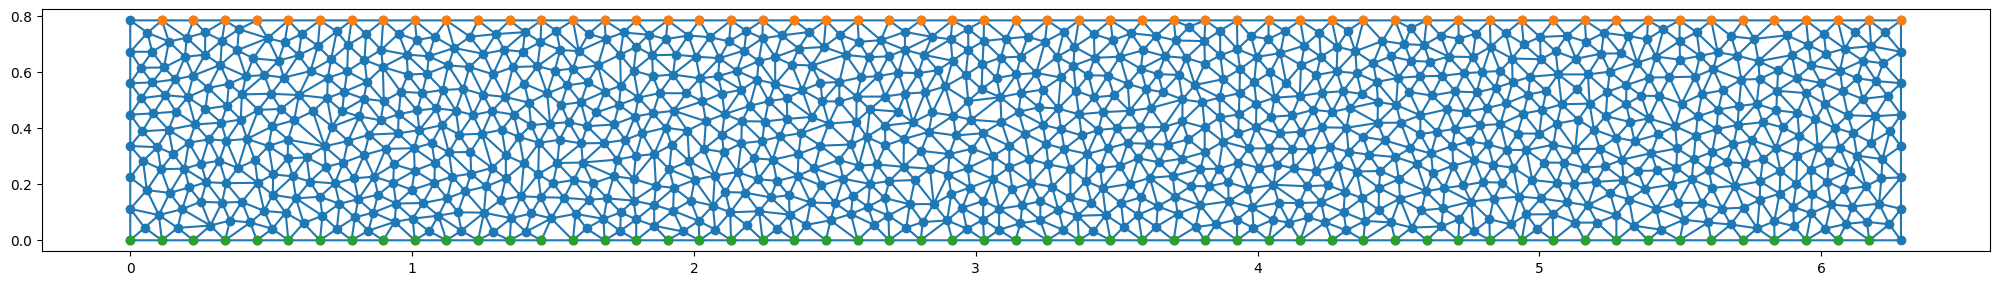

In [424]:
#pts2d,nghost=init(N,lenx,leny,bdry)
#pts2d,nghost=run_init_eq(N,lenx,leny,sigma,eps,rc,dfac,kBT,onemciter,totmciter,bdry)
tri,sortednbrs=triangulate(pts2d,nghost,lenx,leny,bdry)
bdryloop=bdryindices(N,lenx,leny,bdry)

#check the surface
plt.figure(figsize=(4*lenx,4*leny))
plt.triplot(pts2d[:,0],pts2d[:,1],tri)
plt.scatter(pts2d[:,0],pts2d[:,1],marker="o")
plt.scatter(pts2d[bdryloop["top"],0],pts2d[bdryloop["top"],1],marker="o")
plt.scatter(pts2d[bdryloop["bot"],0],pts2d[bdryloop["bot"],1],marker="o")

plt.show()

### Post-Processing the Triangulation According to Desired Geometry (Periodic)

In [354]:
#helper functions

def find_nbrs(vertind,sortednbrs):
    return sortednbrs[vertind]

def find_tris(vertind,tri):
    return tri[np.any(tri==vertind,axis=1)]
    

In [490]:
#we note, our purpose of using the rect boundary condition was to be able to wrap it around.
#now, we have a set of points overlapping at 0 and 2pi.
#we need to merge those and reassign their neighbour list accordingly.

#use for rect (wrapping) boundary condition
def remap_x(pts2d,sortednbrs,tri,geometry="cyl"): #geometry will be cyl or mobius. the mapping will be straight or twisted accordingly.
    left_bd=np.where(np.isclose(pts2d[:,0],0))[0]
    right_bd=np.where(np.isclose(pts2d[:,0],lenx))[0]

    newtri = tri.copy()
    newnbrs = [list(nbrs) for nbrs in sortednbrs]
    
    #print(left_bd)
    #print(right_bd)
    
    left_sorted=left_bd[np.argsort(pts2d[left_bd][:, 1])]
    right_sorted=right_bd[np.argsort(pts2d[right_bd][:, 1])]
    
    lenbd=len(left_sorted)
    
    if geometry=="cyl":
        pass
    elif geometry=="mobius":
        #reverse one of the arrays
        right_sorted=right_sorted[::-1]

    for i in range(lenbd):
        leftpt=left_sorted[i]
        rightpt=right_sorted[i]

        leftnbrs=set(sortednbrs[leftpt])
        rightnbrs=set(sortednbrs[rightpt])
        
        mergednbrs=leftnbrs.union(rightnbrs)
        nodenbrs=list(mergednbrs)

        #sort neighbours again
        dx=pts2d[nodenbrs,0]-pts2d[leftpt,0]
        dx=dx-lenx*np.round(dx/lenx) #wrap-around for x direction
        dy=pts2d[nodenbrs,1]-pts2d[leftpt,1]

        angles=np.arctan2(dy,dx)

        sortednodenbrs=np.array(nodenbrs)[np.argsort(angles)]
        newnbrs[leftpt]=sortednodenbrs.tolist()
        newnbrs[rightpt]=sortednodenbrs.tolist()

        lefttri=find_tris(leftpt,tri)
        righttri=find_tris(rightpt,tri)

        newtri[newtri==rightpt] = leftpt
        
    return newtri,newnbrs            
    

#print(pts2d[left_bd])
#print(pts2d[right_bd])

#plt.figure(figsize=(4*lenx,4*leny))
#plt.triplot(pts2d[:,0],pts2d[:,1],tri)
#plt.scatter(pts2d[:,0],pts2d[:,1],marker="o")
#plt.scatter(pts2d[left_bd,0],pts2d[left_bd,1],marker="o")
#plt.scatter(pts2d[right_bd,0],pts2d[right_bd,1],marker="o")
#plt.show()


### Alternative: Initialising with Regular Hexagonal Grid

In [492]:
def hexgrid(lenx,leny,spacing):
    pts=[]
    drow=spacing*np.sqrt(3)/2.0  #spacing between rows would be bond length*sqrt(3)/2
    nrows=int(np.ceil(leny/drow))
    for r in range(nrows):
        y=r*drow
        if y>leny:
            break

        #shift every alternate row
        x_shift=0.5*spacing if (r%2==1) else 0.0
        x=x_shift
        while x<=lenx:
            pts.append([x,y])
            x+=spacing
    return np.array(pts)

pts2d_reg=hexgrid(lenx,leny,sigma)

N_reg=len(pts2d_reg) 

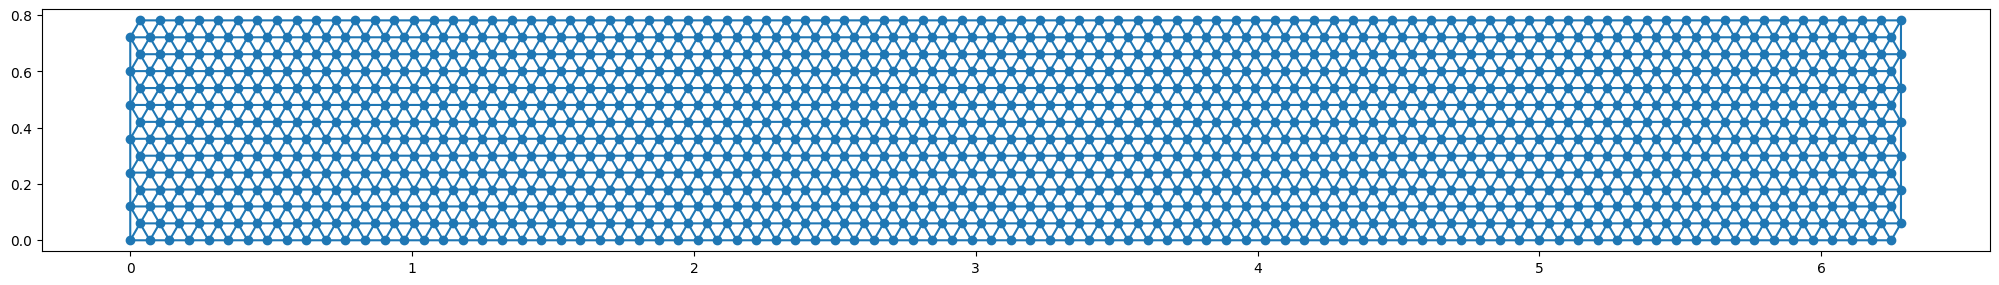

In [493]:
nghost_reg=0
tri_reg, sortednbrs_reg = triangulate(pts2d_reg, nghost_reg, lenx, leny, bdry)
bdryloop_reg = bdryindices(N, lenx, leny, bdry)

plt.figure(figsize=(4*lenx, 4*leny))
plt.triplot(pts2d_reg[:,0], pts2d_reg[:,1], tri_reg)
plt.scatter(pts2d_reg[:,0], pts2d_reg[:,1], marker="o")
plt.show()

### Mapping the Triangulated Mesh to the Desired Surface

We use the parametric representations of the surface, and suitably transform the x,y coordinates to the u,v parametric coordinates. 

In [494]:
#cylinder
def map_cyl(pts2d,lenx,leny):
    N=len(pts2d)
    pts3d=np.zeros((N,3))

    R=lenx/(2*np.pi)
    theta=(pts2d[:,0]/lenx)*2*np.pi

    pts3d[:,0]=R*np.cos(theta)
    pts3d[:,1]=R*np.sin(theta)
    pts3d[:,2]=pts2d[:,1] #the height coordinate

    return pts3d

#cylinder with an added wave to the boundary
def map_skew_cyl(pts2d,lenx,leny):
    N=len(pts2d)
    pts3d=np.zeros((N,3))

    R=lenx/(2*np.pi)
    theta=(pts2d[:,0]/lenx)*2*np.pi

    pts3d[:,0]=R*np.cos(theta)
    pts3d[:,1]=R*np.sin(theta)
    pts3d[:,2]=pts2d[:,1]+np.sin(2*theta) #the height coordinate

    return pts3d

#mobius strip
def map_mobius(pts2d,lenx,leny):
    N=len(pts2d)
    pts3d=np.zeros((N,3))
    R=lenx/(2*np.pi)
    theta=(pts2d[:,0]/lenx)*2*np.pi
    u=theta
    v=pts2d[:,1]-(leny/2.0) #bring the middle down to the centerline

    pts3d[:,0]=(R+v*np.cos(u/2))*np.cos(u)
    pts3d[:,1]=(R+v*np.cos(u/2))*np.sin(u)
    pts3d[:,2]=v*np.sin(u/2)
    return pts3d

### Visualising the Maps (Random Grid and Regular Grid)

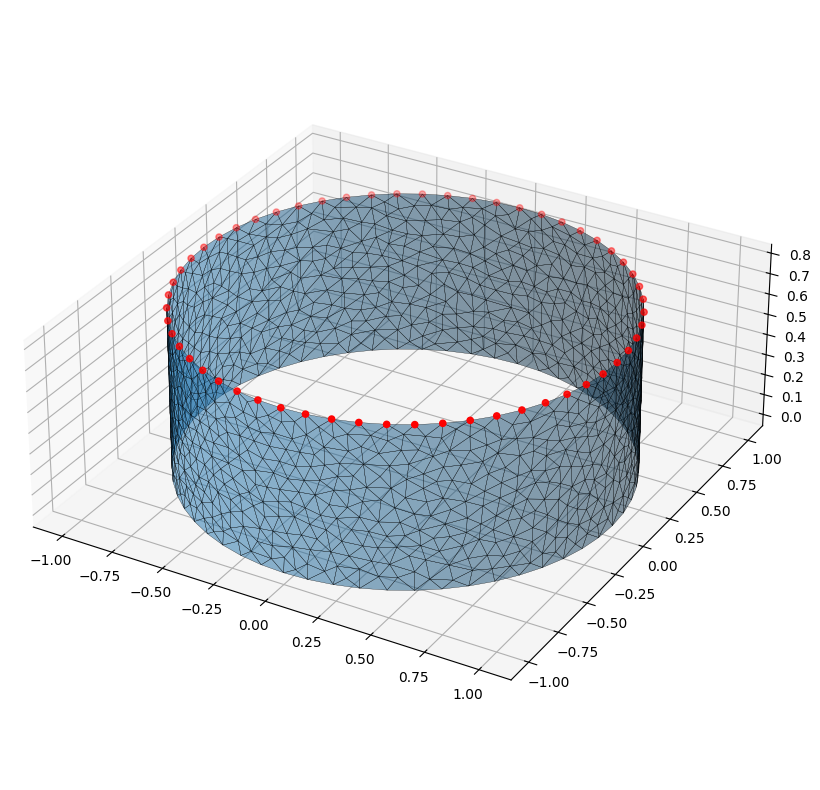

In [495]:
#cylinder
pts3d=map_cyl(pts2d,lenx,leny)
newtri,newnbrs=remap_x(pts2d,sortednbrs,tri,"cyl")

fig=plt.figure(figsize=(10,8))
ax=fig.add_subplot(111,projection='3d')
surf = ax.plot_trisurf(
    pts3d[:, 0], pts3d[:, 1], pts3d[:, 2], 
    triangles=newtri, 
    edgecolor='black',       
    linewidth=0.2, 
    alpha=0.5)      

bdrytop=bdryloop["top"]
ax.scatter(pts3d[bdrytop,0],pts3d[bdrytop,1],pts3d[bdrytop,2],color="red")

diameter = lenx / np.pi
ax.set_box_aspect([1, 1, leny / diameter]) 

plt.tight_layout()
plt.show()

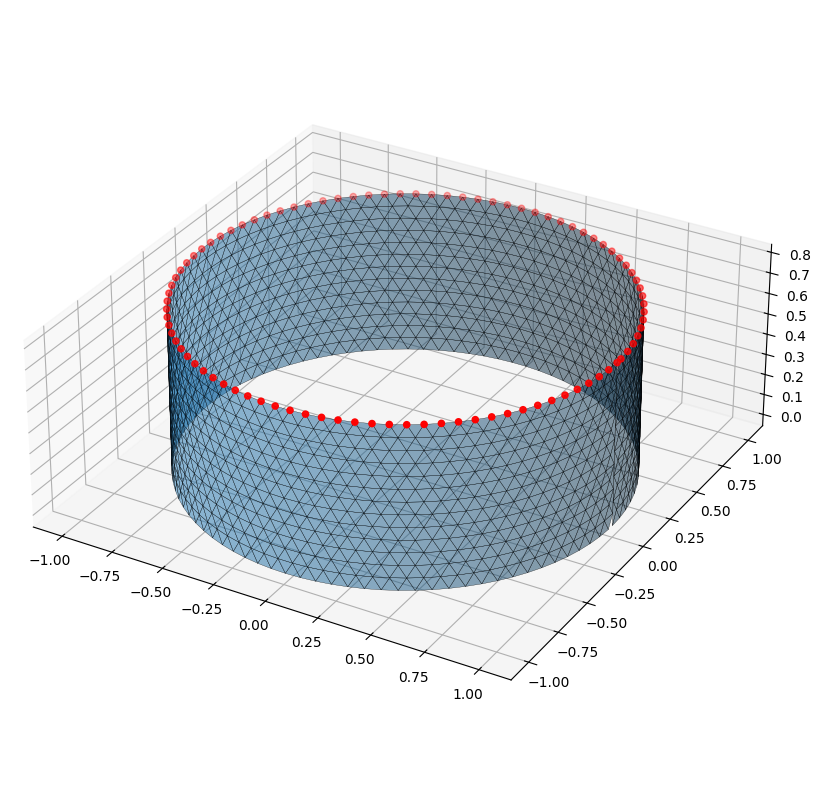

In [479]:
#cylinder
pts3d=map_cyl(pts2d_reg,lenx,leny)
#newtri,newnbrs=remap_x(pts2d_reg,sortednbrs_reg,tri_reg,"cyl")
max_y = np.max(pts2d_reg[:, 1])
bdrytop = np.where(np.abs(pts2d_reg[:, 1] - max_y) < 1e-5)[0]
bdrytop = bdrytop[np.argsort(pts2d_reg[bdrytop, 0])]

fig=plt.figure(figsize=(10,8))
ax=fig.add_subplot(111,projection='3d')
surf = ax.plot_trisurf(
    pts3d[:, 0], pts3d[:, 1], pts3d[:, 2], 
    triangles=tri_reg, 
    edgecolor='black',       
    linewidth=0.2, 
    alpha=0.5)      

#bdrytop=bdryloop_reg["top"]
ax.scatter(pts3d[bdrytop,0],pts3d[bdrytop,1],pts3d[bdrytop,2],color="red")

diameter = lenx / np.pi
ax.set_box_aspect([1, 1, leny / diameter]) 

plt.tight_layout()
plt.show()

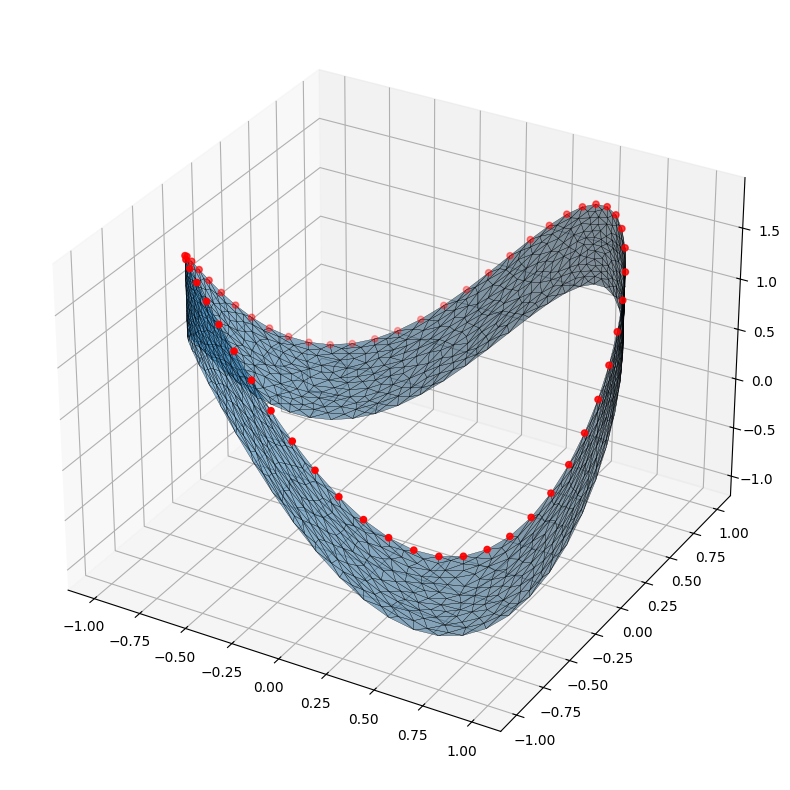

In [449]:
#cylinder with an added wave to the boundary
pts3d=map_skew_cyl(pts2d,lenx,leny)
newtri,newnbrs=remap_x(pts2d,sortednbrs,tri,"cyl")

fig=plt.figure(figsize=(10,8))
ax=fig.add_subplot(111,projection='3d')
surf = ax.plot_trisurf(
    pts3d[:, 0], pts3d[:, 1], pts3d[:, 2], 
    triangles=newtri, 
    edgecolor='black',       
    linewidth=0.2, 
    alpha=0.5)             

ax.scatter(pts3d[bdrytop,0],pts3d[bdrytop,1],pts3d[bdrytop,2],color="red")

diameter = lenx / np.pi
#ax.set_box_aspect([1, 1, leny / diameter]) 

plt.tight_layout()
plt.show()

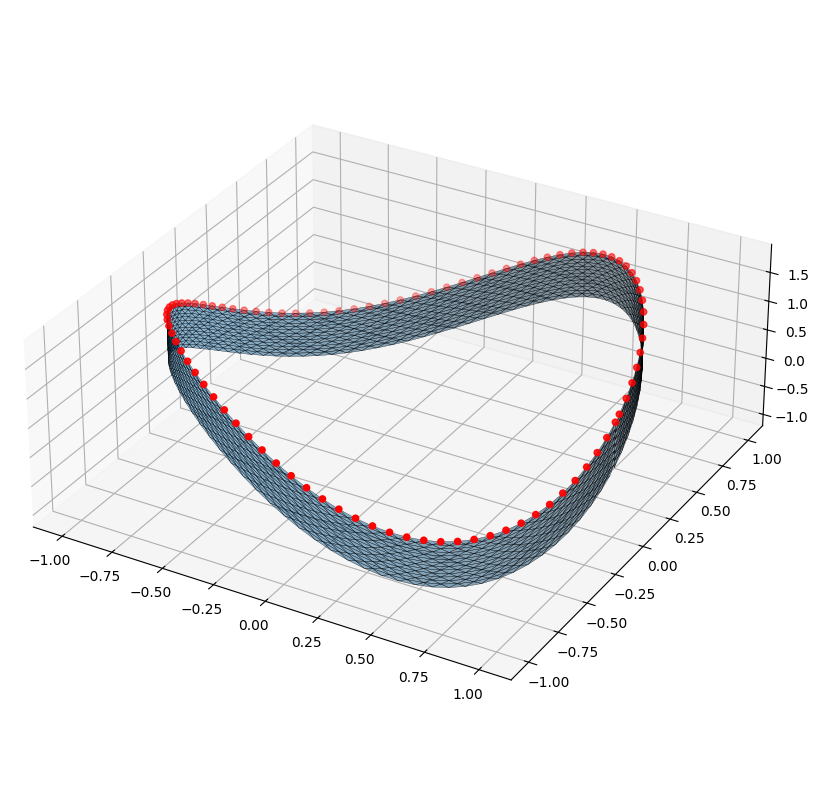

In [496]:
#skewed cylinder
pts3d=map_skew_cyl(pts2d_reg,lenx,leny)
#newtri,newnbrs=remap_x(pts2d_reg,sortednbrs_reg,tri_reg,"cyl")
max_y = np.max(pts2d_reg[:, 1])
bdrytop = np.where(np.abs(pts2d_reg[:, 1] - max_y) < 1e-5)[0]
bdrytop = bdrytop[np.argsort(pts2d_reg[bdrytop, 0])]

fig=plt.figure(figsize=(10,8))
ax=fig.add_subplot(111,projection='3d')
surf = ax.plot_trisurf(
    pts3d[:, 0], pts3d[:, 1], pts3d[:, 2], 
    triangles=tri_reg, 
    edgecolor='black',       
    linewidth=0.2, 
    alpha=0.5)      

#bdrytop=bdryloop_reg["top"]
ax.scatter(pts3d[bdrytop,0],pts3d[bdrytop,1],pts3d[bdrytop,2],color="red")

diameter = lenx / np.pi
ax.set_box_aspect([1, 1, leny / diameter]) 

plt.tight_layout()
plt.show()

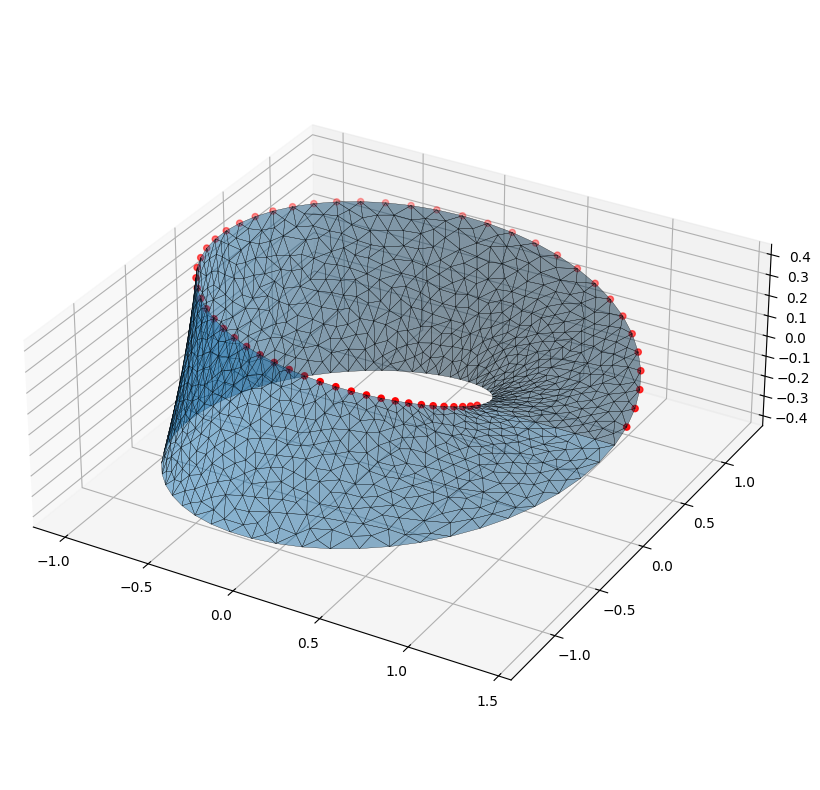

In [360]:
#mobius strip parametrisation
pts3d=map_mobius(pts2d,lenx,leny)
newtri,newnbrs=remap_x(pts2d,sortednbrs,tri,"mobius")

fig=plt.figure(figsize=(10,8))
ax=fig.add_subplot(111,projection='3d')

surf = ax.plot_trisurf(
    pts3d[:, 0], pts3d[:, 1], pts3d[:, 2], 
    triangles=newtri, 
    edgecolor='black',       
    linewidth=0.2, 
    alpha=0.5)

ax.scatter(pts3d[bdryloop["top"],0],pts3d[bdryloop["top"],1],pts3d[bdryloop["top"],2],color="red")

diameter = lenx / np.pi
ax.set_box_aspect([1, 1, leny / diameter]) 

plt.tight_layout()
plt.show()

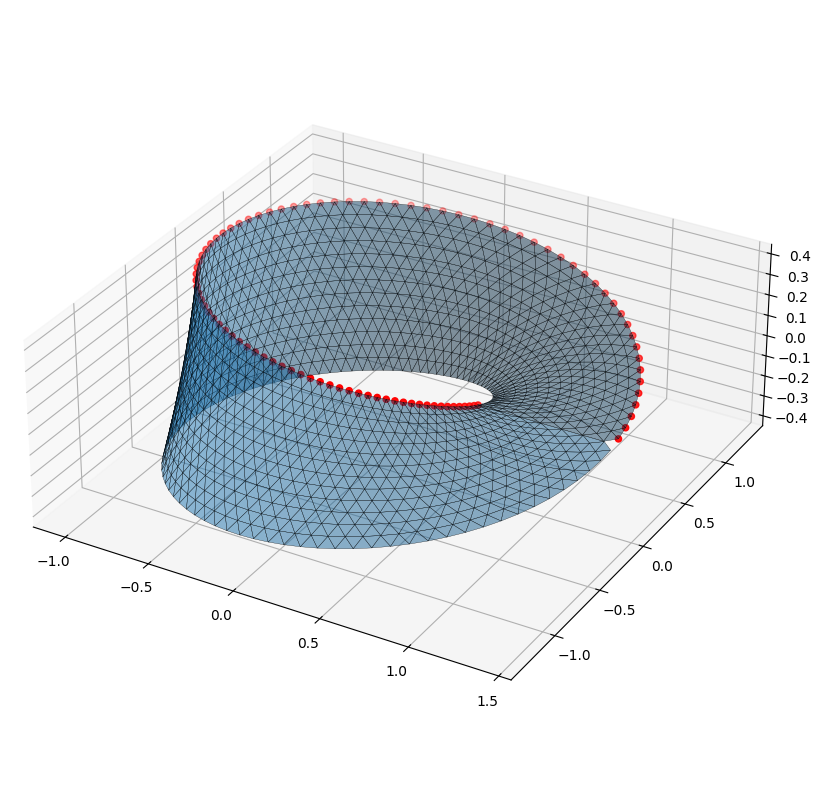

In [480]:
#mobius strip parametrisation
pts3d=map_mobius(pts2d_reg,lenx,leny)
max_y = np.max(pts2d_reg[:, 1])
bdrytop = np.where(np.abs(pts2d_reg[:, 1] - max_y) < 1e-5)[0]
bdrytop = bdrytop[np.argsort(pts2d_reg[bdrytop, 0])]
#newtri,newnbrs=remap_x(pts2d,sortednbrs,tri,"mobius")

fig=plt.figure(figsize=(10,8))
ax=fig.add_subplot(111,projection='3d')

surf = ax.plot_trisurf(
    pts3d[:, 0], pts3d[:, 1], pts3d[:, 2], 
    triangles=tri_reg, 
    edgecolor='black',       
    linewidth=0.2, 
    alpha=0.5)

ax.scatter(pts3d[bdrytop,0],pts3d[bdrytop,1],pts3d[bdrytop,2],color="red")

diameter = lenx / np.pi
ax.set_box_aspect([1, 1, leny / diameter]) 

plt.tight_layout()
plt.show()

## Finding the Geodesic Curvature Along the Boundary

### Approach 1: 
We evaluate $\frac{dT}{ds}\cdot(\vec{N}\times\vec{T})$ directly at the vertices. In order to define the normal at a vertex, we use the area-weighted average of the normals of the triangles connected to this vertex. 

In [259]:
#we will work with the space coordinates of each point in 3D

#evaluate normal at a node
def normalvec(vertind,pts3d,tri):
    triangles=find_tris(vertind,tri)
    normal=np.zeros(3)
    for triangle in triangles:
        vind1=triangle[0]
        vind2=triangle[1]
        vind3=triangle[2]
        v1=pts3d[vind1]
        v2=pts3d[vind2]
        v3=pts3d[vind3]
        e1=v2-v1
        e2=v3-v1
        ntri=np.cross(e1,e2)
        ntrinorm=np.linalg.norm(ntri)
        if ntrinorm!=0:
            ntri/=ntrinorm #we get the normalized unit vector
        area=ntrinorm/2
        normal+=area*ntri
    normnormal=np.linalg.norm(normal)
    if normnormal!=0:
        normal/=normnormal #get the unit normal
    return normal

In [260]:
#evaluate tangents at a node
def tangents(vertind,bdry,tri,pts3d):
    nb=len(bdry)
    ind=np.where(bdry==vertind)[0][0]

    pvert=pts3d[bdry[(ind-1)%nb]]
    nvert=pts3d[bdry[(ind+1)%nb]]
    pvert2=pts3d[bdry[(ind-2)%nb]]
    nvert2=pts3d[bdry[(ind+2)%nb]]

    vert=pts3d[vertind]
    '''
    normin=np.linalg.norm(t_in)
    normout=np.linalg.norm(t_out)
    normin2=np.linalg.norm(t_in2)
    normout2=np.linalg.norm(t_out2)
    '''
    tan3=threept_fd1(pvert,vert,nvert)
    dtds3=threept_fd2(pvert,vert,nvert)

    tan5=fivept_fd1(pvert2,pvert,vert,nvert,nvert2)
    dtds5=fivept_fd2(pvert2,pvert,vert,nvert,nvert2)
       

    return tan3,dtds3,tan5,dtds5

In [261]:
def bdrylocalgc(vertind,pts3d,bdryloop,tri,order=3):
    #global bdryloop,tri,pts3d
    tan3,dtds3,tan5,dtds5=tangents(vertind,bdryloop,tri,pts3d)
    normal=normalvec(vertind,pts3d,tri)
    #tan3/=np.linalg.norm(tan3)
    #tan5/=np.linalg.norm(tan5)
    if order==3:
        tangent=tan3/np.linalg.norm(tan3)
        kappa=dtds3
    elif order==5:
        tangent=tan5/np.linalg.norm(tan5)
        kappa=dtds5
    temp=np.cross(normal,tangent)
    gc=np.dot(kappa,temp)
    return gc   

#### Test Case 1: Skewed Cylinder

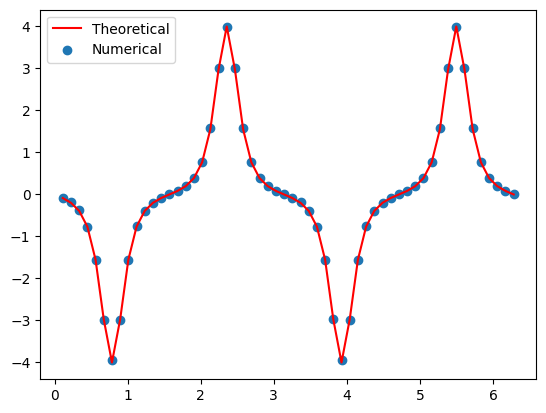

In [477]:
pts3d=map_skew_cyl(pts2d,lenx,leny)
newtri,newnbrs=remap_x(pts2d,sortednbrs,tri,"cyl")
bdrytop=np.array(bdryindices(N,lenx,leny,bdry)["top"])
bdrypts=pts3d[bdrytop]

length=len(bdrypts)
R=lenx/(2*np.pi)
thetas=np.mod(np.arctan2(bdrypts[:,1],bdrypts[:,0]),2*np.pi)


gcs=np.zeros_like(thetas)
for i in range(length):
    ptind=bdrytop[i]
    gcs[i]=bdrylocalgc(ptind,pts3d,bdrytop,newtri,order=5)

#func=-np.sin(thetas)/(R*((1+np.cos(thetas)*np.cos(thetas))**1.5))
func=-4*np.sin(2*thetas)/(R*((1+4*np.cos(2*thetas)*np.cos(2*thetas))**1.5))

#thetas=np.array(sorted(thetas))
plt.plot(thetas,func,color="red",label="Theoretical")

plt.scatter(thetas,gcs,marker="o",label="Numerical")
plt.legend()
plt.show()

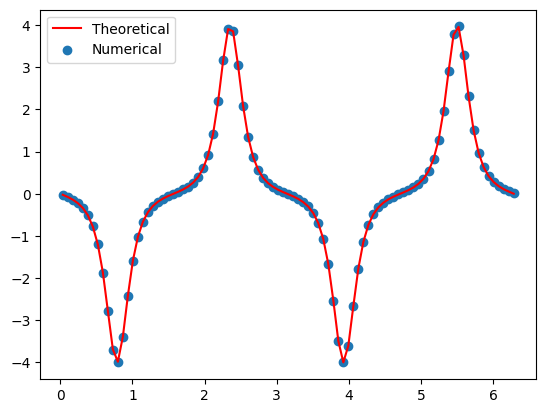

In [497]:
pts3d=map_skew_cyl(pts2d_reg,lenx,leny)
max_y=np.max(pts2d_reg[:, 1])
bdrytop=np.where(np.abs(pts2d_reg[:, 1]-max_y)<1e-5)[0]
bdrytop=bdrytop[np.argsort(pts2d_reg[bdrytop, 0])]

bdrypts = pts3d[bdrytop]

length=len(bdrypts)
R=lenx/(2*np.pi)
thetas=np.mod(np.arctan2(bdrypts[:,1],bdrypts[:,0]),2*np.pi)


gcs=np.zeros_like(thetas)
for i in range(length):
    ptind=bdrytop[i]
    gcs[i]=bdrylocalgc(ptind,pts3d,bdrytop,tri_reg,order=5)

#func=-np.sin(thetas)/(R*((1+np.cos(thetas)*np.cos(thetas))**1.5))
func=-4*np.sin(2*thetas)/(R*((1+4*np.cos(2*thetas)*np.cos(2*thetas))**1.5))

#thetas=np.array(sorted(thetas))
plt.plot(thetas,func,color="red",label="Theoretical")

plt.scatter(thetas,gcs,marker="o",label="Numerical")
plt.legend()
plt.show()

#### Test Case 2: Mobius Strip

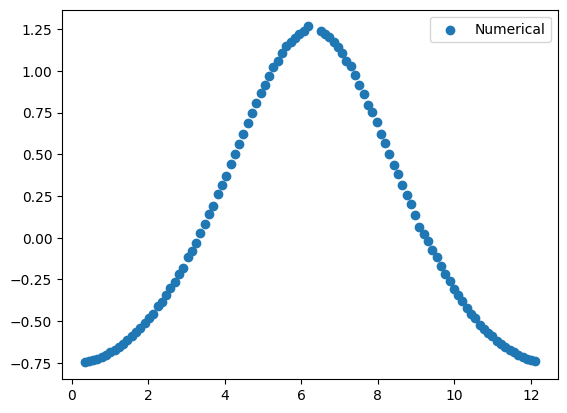

In [498]:
pts3d=map_mobius(pts2d,lenx,leny)
newtri,newnbrs=remap_x(pts2d,sortednbrs,tri,"mobius")
bdrytop=np.array(bdryindices(N,lenx,leny,bdry)["top"])
bdrybot=np.array(bdryindices(N,lenx,leny,bdry)["bot"])

toppts=pts3d[bdrytop]
botpts=pts3d[bdrybot]

thetas_top=np.mod(np.arctan2(pts3d[bdrytop,1], pts3d[bdrytop,0]), 2*np.pi)
thetas_bot=np.mod(np.arctan2(pts3d[bdrybot,1], pts3d[bdrybot,0]), 2*np.pi)

bdrytop_sorted=bdrytop[np.argsort(thetas_top)]
bdrybot_sorted=bdrybot[np.argsort(thetas_bot)[::-1]]

fullbdry = np.concatenate([bdrytop_sorted, bdrybot_sorted])

length=len(fullbdry)

thetas=np.concatenate([
    np.sort(thetas_top),
    np.sort(thetas_bot)[::-1]+2*np.pi
])

R=lenx/(2*np.pi)
w=leny/2
gcs=np.zeros_like(thetas)

'''
length=len(bdrypts)
R=lenx/(2*np.pi)
thetas=np.mod(np.arctan2(bdrypts[:,1],bdrypts[:,0]),2*np.pi)
'''
junction=length//2   #index where top meets bottom
'''
skip=[0,1,length-1,length-2,
                   junction-1, junction, junction+1, junction+2]
'''

skip=[]

for i in range(length):
    ptind=fullbdry[i]
    if i in skip:
        gcs[i] = np.nan #for now skip the joint points, will have to see what to do about this
    else:
        gcs[i]=bdrylocalgc(ptind,pts3d,fullbdry,newtri,order=5)

#print(thetas/np.pi)
plt.scatter(thetas,gcs,marker="o",label="Numerical")
#plt.scatter(thetas,kg_analytical,label='Analytical')
plt.legend()
plt.show()


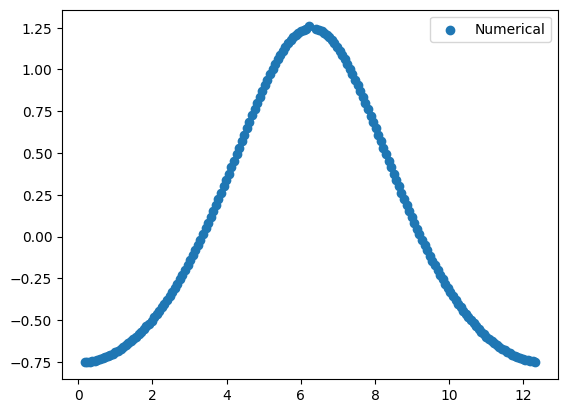

In [502]:
pts3d=map_mobius(pts2d_reg,lenx,leny)
#newtri,newnbrs=remap_x(pts2d,sortednbrs,tri,"mobius")
max_y=np.max(pts2d_reg[:, 1])
bdrytop=np.where(np.abs(pts2d_reg[:, 1] - max_y) < 1e-5)[0]
bdrytop=bdrytop[np.argsort(pts2d_reg[bdrytop, 0])]
min_y=np.min(pts2d_reg[:, 1])
bdrybot=np.where(np.abs(pts2d_reg[:, 1] - min_y) < 1e-5)[0]
bdrybot=bdrybot[np.argsort(pts2d_reg[bdrybot, 0])]

toppts=pts3d[bdrytop]
botpts=pts3d[bdrybot]

thetas_top=np.mod(np.arctan2(pts3d[bdrytop,1], pts3d[bdrytop,0]), 2*np.pi)
thetas_bot=np.mod(np.arctan2(pts3d[bdrybot,1], pts3d[bdrybot,0]), 2*np.pi)

bdrytop_sorted=bdrytop[np.argsort(thetas_top)]
bdrybot_sorted=bdrybot[np.argsort(thetas_bot)[::-1]]

fullbdry = np.concatenate([bdrytop_sorted, bdrybot_sorted])

length=len(fullbdry)

thetas=np.concatenate([
    np.sort(thetas_top),
    np.sort(thetas_bot)[::-1]+2*np.pi
])

R=lenx/(2*np.pi)
w=leny/2
gcs=np.zeros_like(thetas)

'''
length=len(bdrypts)
R=lenx/(2*np.pi)
thetas=np.mod(np.arctan2(bdrypts[:,1],bdrypts[:,0]),2*np.pi)
'''
junction=length//2   #index where top meets bottom

skip=[0,1,length-1,length-2,
                   junction-1, junction, junction+1, junction+2]

for i in range(length):
    ptind=fullbdry[i]
    if i in skip:
        gcs[i] = np.nan #for now skip the joint points, will have to see what to do about this
    else:
        gcs[i]=bdrylocalgc(ptind,pts3d,fullbdry,tri_reg,order=5)


#print(thetas/np.pi)
plt.scatter(thetas,gcs,marker="o",label="Numerical")
#plt.scatter(thetas,kg_analytical,label='Analytical')
plt.legend()
plt.show()


### Approach 2

We compute the geodesic curvature at the midpoint between two vertices. The midpoint is part of a single well-defined triangle, as a result we have a unique well-defined normal. The tangent and curvature vector are computed by the finite difference formulae at each end vertex of the edge, and interpolated at the midpoint.

In [297]:
def normal_midpt(vertind1,vertind2,tri,pts3d):
    tri1=find_tris(vertind1,tri)
    tri2=find_tris(vertind2,tri)

    tris=[]
    for triangle in tri1:
        if vertind2 in triangle:
            tris.append(triangle)

    if len(tris) == 0:
        print(vertind1,vertind2)
        return np.zeros(3)
            
    triangle=tris[0]
    normal=np.zeros(3)
    vind1=triangle[0]
    vind2=triangle[1]
    vind3=triangle[2]
    v1=pts3d[vind1]
    v2=pts3d[vind2]
    v3=pts3d[vind3]
    e1=v2-v1
    e2=v3-v1
    ntri=np.cross(e1,e2)

    midpt=(pts3d[vertind1]+pts3d[vertind2])/2
    radial=midpt.copy() #midpoint onto xy plane
    radial[2]=0
    #ensure we have the outward normal
    if np.linalg.norm(radial)>1e-12:
        radial/=np.linalg.norm(radial)
    if np.dot(ntri,radial)<0:
        ntri=-ntri 
    ntrinorm=np.linalg.norm(ntri)
    if ntrinorm!=0:
        ntri/=ntrinorm #we get the normalized unit vector
        

    return ntri

In [298]:
def tangents_midpt(vertind1,vertind2,bdryloop,tri,pts3d):
    nb=len(bdryloop)
    
    ind1=np.where(bdryloop==vertind1)[0][0]
    ind2=np.where(bdryloop==vertind2)[0][0]
    
    vert1=pts3d[vertind1]
    vert2=pts3d[vertind2]

    pvert1=pts3d[bdryloop[(ind1-1)%nb]]
    nvert1=pts3d[bdryloop[(ind1+1)%nb]]
    ppvert1=pts3d[bdryloop[(ind1-2)%nb]]
    nnvert1=pts3d[bdryloop[(ind1+2)%nb]]
    
    pvert2=pts3d[bdryloop[(ind2-1)%nb]]
    nvert2=pts3d[bdryloop[(ind2+1)%nb]]
    ppvert2=pts3d[bdryloop[(ind2-2)%nb]]
    nnvert2=pts3d[bdryloop[(ind2+2)%nb]]

    #three point formulae
    tan3_1=threept_fd1(pvert1,vert1,nvert1)
    tan3_2=threept_fd1(pvert2,vert2,nvert2)
    dtds3_1=threept_fd2(pvert1,vert1,nvert1)
    dtds3_2=threept_fd2(pvert2,vert2,nvert2)

    #interpolate the derivatives at the midpoint
    tan3=0.5*(tan3_1+tan3_2)
    dtds3=0.5*(dtds3_1+dtds3_2)

    #five point formulae
    tan5_1=fivept_fd1(ppvert1,pvert1,vert1,nvert1,nnvert1)
    tan5_2=fivept_fd1(ppvert2,pvert2,vert2,nvert2,nnvert2)
    dtds5_1=fivept_fd2(ppvert1,pvert1,vert1,nvert1,nnvert1)
    dtds5_2=fivept_fd2(ppvert2,pvert2,vert2,nvert2,nnvert2)

    #interpolate the derivatives at the midpoint
    tan5=0.5*(tan5_1+tan5_2)
    dtds5=0.5*(dtds5_1+dtds5_2)

    return tan3,dtds3,tan5,dtds5
    

In [299]:
def bdrylocalgc_midpt(vertind,pts3d,bdryloop,tri,order=3):
    nb=len(bdryloop)

    ind=np.where(bdryloop==vertind)[0][0]

    pvertind=bdryloop[(ind-1)%nb]
    nvertind=bdryloop[(ind+1)%nb]

    vert=pts3d[vertind]
    pvert=pts3d[pvertind]
    nvert=pts3d[nvertind]

    norm1=normal_midpt(pvertind,vertind,tri,pts3d)
    tan3_1,dtds3_1,tan5_1,dtds5_1=tangents_midpt(pvertind,vertind,bdryloop,tri,pts3d)
    tan3_1/=np.linalg.norm(tan3_1)
    tan5_1/=np.linalg.norm(tan5_1)
    if order==3:
        tan1=tan3_1
        kappa1=dtds3_1
    elif order==5:
        tan1=tan5_1
        kappa1=dtds5_1
    temp1=np.cross(norm1,tan1)
    gc1=np.dot(kappa1,temp1)
    
    norm2=normal_midpt(vertind,nvertind,tri,pts3d)
    tan3_2,dtds3_2,tan5_2,dtds5_2=tangents_midpt(vertind,nvertind,bdryloop,tri,pts3d)
    tan3_2/=np.linalg.norm(tan3_2)
    tan5_2/=np.linalg.norm(tan5_2)
    if order==3:
        tan2=tan3_2
        kappa2=dtds3_2
    elif order==5:
        tan2=tan5_2
        kappa2=dtds5_2
    temp2=np.cross(norm2,tan2)
    gc2=np.dot(kappa2,temp2)

    return (gc1*np.linalg.norm(vert-pvert)+gc2*np.linalg.norm(nvert-vert))/(np.linalg.norm(vert-pvert)+np.linalg.norm(nvert-vert))

#### Test Case 1: Skewed Cylinder

111 56
110 111
110 111
111 56


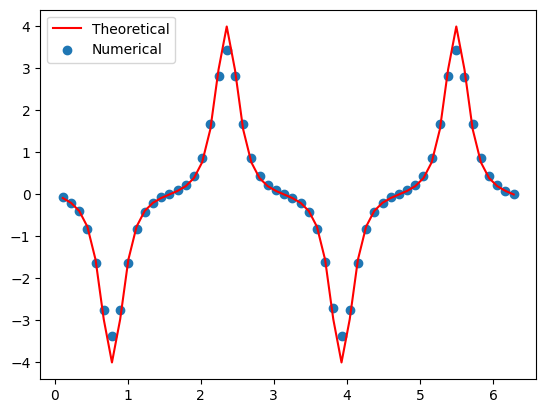

In [407]:
pts3d=map_skew_cyl(pts2d,lenx,leny)
bdrytop=np.array(bdryindices(N,lenx,leny,bdry)["top"])
bdrypts=pts3d[bdrytop]

length=len(bdrypts)
R=lenx/(2*np.pi)
thetas=np.mod(np.arctan2(bdrypts[:,1],bdrypts[:,0]),2*np.pi)

newtri,newnbrs=remap_x(pts2d,sortednbrs,tri,"cyl")

gcs=np.zeros_like(thetas)
for i in range(length):
    ptind=bdrytop[i]
    gcs[i]=bdrylocalgc_midpt(ptind,pts3d,bdrytop,newtri,order=5)

#func=-np.sin(thetas)/(R*((1+np.cos(thetas)*np.cos(thetas))**1.5))
func=-4*np.sin(2*thetas)/(R*((1+4*np.cos(2*thetas)*np.cos(2*thetas))**1.5))

#thetas=np.array(sorted(thetas))
plt.plot(thetas,func,color="red",label="Theoretical")

plt.scatter(thetas,gcs,marker="o",label="Numerical")
plt.legend()
plt.show()

1273 1183
1273 1183


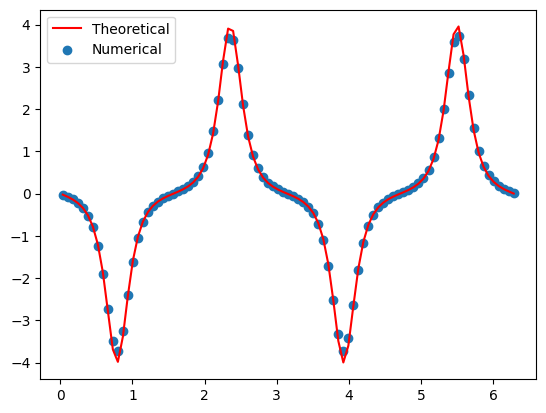

In [501]:
pts3d=map_skew_cyl(pts2d_reg,lenx,leny)
max_y=np.max(pts2d_reg[:, 1])
bdrytop=np.where(np.abs(pts2d_reg[:, 1]-max_y)<1e-5)[0]
bdrytop=bdrytop[np.argsort(pts2d_reg[bdrytop, 0])]

# Ensure the extracted points are sorted by their angle (theta) so the plot line doesn't zigzag
bdrypts = pts3d[bdrytop]

length=len(bdrypts)
R=lenx/(2*np.pi)
thetas=np.mod(np.arctan2(bdrypts[:,1],bdrypts[:,0]),2*np.pi)


gcs=np.zeros_like(thetas)
for i in range(length):
    ptind=bdrytop[i]
    gcs[i]=bdrylocalgc_midpt(ptind,pts3d,bdrytop,tri_reg,order=5)

#func=-np.sin(thetas)/(R*((1+np.cos(thetas)*np.cos(thetas))**1.5))
func=-4*np.sin(2*thetas)/(R*((1+4*np.cos(2*thetas)*np.cos(2*thetas))**1.5))

#thetas=np.array(sorted(thetas))
plt.plot(thetas,func,color="red",label="Theoretical")

plt.scatter(thetas,gcs,marker="o",label="Numerical")
plt.legend()
plt.show()

#### Test Case 2: Mobius Strip

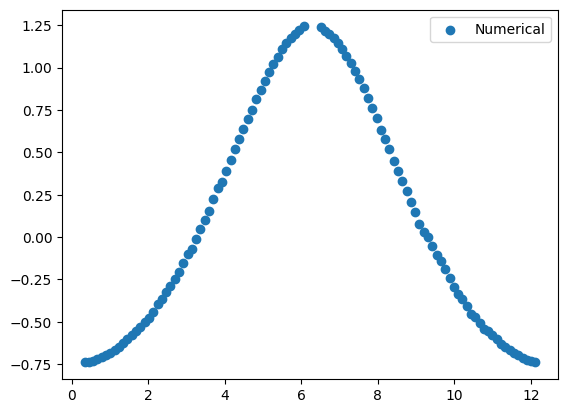

In [503]:
pts3d=map_mobius(pts2d,lenx,leny)
newtri,newnbrs=remap_x(pts2d,sortednbrs,tri,"mobius")
bdrytop=np.array(bdryindices(N,lenx,leny,bdry)["top"])
bdrybot=np.array(bdryindices(N,lenx,leny,bdry)["bot"])

toppts=pts3d[bdrytop]
botpts=pts3d[bdrybot]

thetas_top=np.mod(np.arctan2(pts3d[bdrytop,1], pts3d[bdrytop,0]), 2*np.pi)
thetas_bot=np.mod(np.arctan2(pts3d[bdrybot,1], pts3d[bdrybot,0]), 2*np.pi)

bdrytop_sorted=bdrytop[np.argsort(thetas_top)]
bdrybot_sorted=bdrybot[np.argsort(thetas_bot)][::-1]

fullbdry=np.concatenate([bdrytop_sorted, bdrybot_sorted])

length=len(fullbdry)

thetas=np.concatenate([
    np.sort(thetas_top),
    np.sort(thetas_bot)[::-1]+2*np.pi
])

R=lenx/(2*np.pi)
w=leny/2
gcs=np.zeros_like(thetas)

'''
length=len(bdrypts)
R=lenx/(2*np.pi)
thetas=np.mod(np.arctan2(bdrypts[:,1],bdrypts[:,0]),2*np.pi)
'''

junction=length//2   # index where top meets bottom

skip=[0,1,length-1,length-2,
                   junction-2,junction-1, junction, junction+1, junction+2]

for i in range(length):
    ptind=fullbdry[i]
    if i in skip:
        gcs[i]=np.nan #for now skip the joint points, will have to see what to do about this
    else:
        gcs[i]=bdrylocalgc_midpt(ptind,pts3d,fullbdry,newtri,order=5)

plt.scatter(thetas,gcs,marker="o",label="Numerical")
#plt.scatter(thetas,kg_analytical, label='Analytical')
plt.legend()
plt.show()

In [2]:
pts3d=map_mobius(pts2d_reg,lenx,leny)
#newtri,newnbrs=remap_x(pts2d,sortednbrs,tri,"mobius")
max_y=np.max(pts2d_reg[:, 1])
bdrytop=np.where(np.abs(pts2d_reg[:, 1] - max_y) < 1e-5)[0]
bdrytop=bdrytop[np.argsort(pts2d_reg[bdrytop, 0])]
min_y=np.min(pts2d_reg[:, 1])
bdrybot=np.where(np.abs(pts2d_reg[:, 1] - min_y) < 1e-5)[0]
bdrybot=bdrybot[np.argsort(pts2d_reg[bdrybot, 0])]

toppts=pts3d[bdrytop]
botpts=pts3d[bdrybot]

thetas_top=np.mod(np.arctan2(pts3d[bdrytop,1], pts3d[bdrytop,0]), 2*np.pi)
thetas_bot=np.mod(np.arctan2(pts3d[bdrybot,1], pts3d[bdrybot,0]), 2*np.pi)

bdrytop_sorted=bdrytop[np.argsort(thetas_top)]
bdrybot_sorted=bdrybot[np.argsort(thetas_bot)[::-1]]

fullbdry = np.concatenate([bdrytop_sorted, bdrybot_sorted])

length=len(fullbdry)

thetas=np.concatenate([
    np.sort(thetas_top),
    np.sort(thetas_bot)[::-1]+2*np.pi
])

R=lenx/(2*np.pi)
w=leny/2
gcs=np.zeros_like(thetas)

'''
length=len(bdrypts)
R=lenx/(2*np.pi)
thetas=np.mod(np.arctan2(bdrypts[:,1],bdrypts[:,0]),2*np.pi)
'''
junction=length//2   # index where top meets bottom
'''
skip=[0,1,length-1,length-2,
                   junction-2,junction-1, junction, junction+1, junction+2]
'''

skip=[]

for i in range(length):
    ptind=fullbdry[i]
    if i in skip:
        gcs[i] = np.nan #for now skip the joint points, will have to see what to do about this
    else:
        gcs[i]=bdrylocalgc_midpt(ptind,pts3d,fullbdry,tri_reg,order=5)


#print(thetas/np.pi)
plt.scatter(thetas,gcs,marker="o",label="Numerical")
#plt.scatter(thetas,kg_analytical,label='Analytical')
plt.legend()
plt.show()


NameError: name 'map_mobius' is not defined